   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
(891, 15)
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')
<class 'pandas.core.

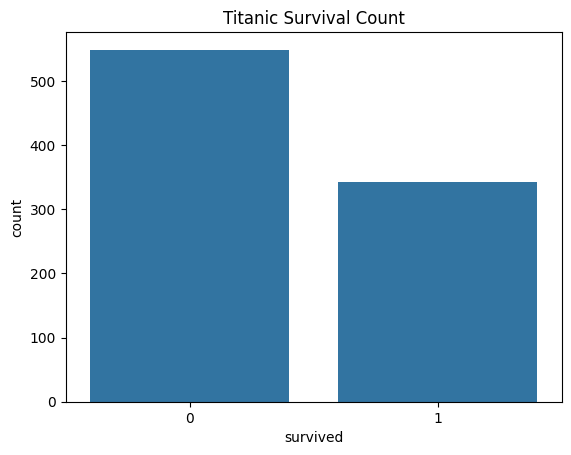

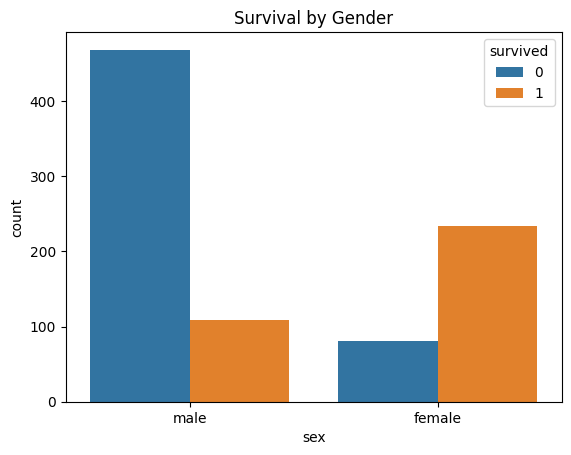

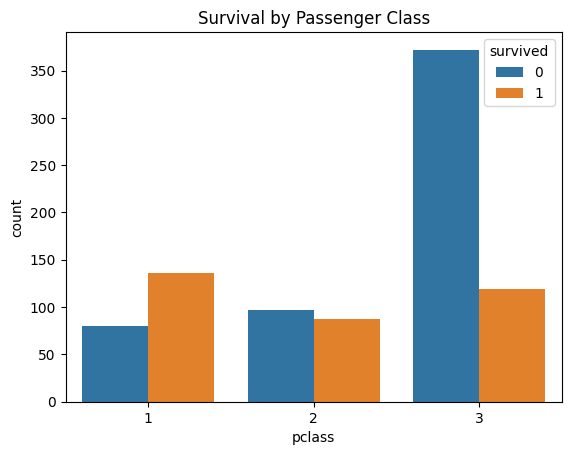

pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64
   pclass   age  sibsp  parch     fare  sex_male  embarked_Q  embarked_S
0       3  22.0      1      0   7.2500      True       False        True
1       1  38.0      1      0  71.2833     False       False       False
2       3  26.0      0      0   7.9250     False       False        True
3       1  35.0      1      0  53.1000     False       False        True
4       3  35.0      0      0   8.0500      True       False        True
Model training completed
[0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1]


In [1]:
#Titanic Survival — Full Logistic Regression Pipeline Project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
#load the dataset
df = pd.read_csv("titanic.csv")
print(df.head())
print(df.shape)
print(df.columns)
#Target (y) = survived
#to understand the data set
print(df.info())
print(df.describe())
print(df.isnull().sum())#check missing values
#EDA
sns.countplot(x="survived", data=df)
plt.title("Titanic Survival Count")
plt.show()
#survival by gender
sns.countplot(x="sex", hue="survived", data=df)
plt.title("Survival by Gender")
plt.show()
sns.countplot(x="pclass", hue="survived", data=df)
plt.title("Survival by Passenger Class")
plt.show()
#select the required features
features = ["pclass","sex","age","sibsp","parch","fare","embarked"]
X = df[features].copy()
y = df["survived"]
#for numer is age use median //missing values
X["age"] = X["age"].fillna(X["age"].median())
#for categorical colum use mode
X["embarked"] = X["embarked"].fillna(X["embarked"].mode()[0])
print(X.isnull().sum())
X = pd.get_dummies(X,columns=["sex", "embarked"],drop_first=True)
print(X.head())
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
    random_state=42,stratify=y)
scaler = StandardScaler()
#Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
print("Model training completed")
y_pred = model.predict(X_test_scaled)
print(y_pred[:20])